# Insurance Claims — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

STYLE = {'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
         'axes.spines.top': False, 'axes.spines.right': False,
         'axes.grid': True, 'grid.alpha': 0.4}
plt.rcParams.update(STYLE)
PALETTE = ['#2563eb', '#7c3aed', '#db2777', '#ea580c', '#16a34a', '#0891b2']

## Load & Prepare Data

In [2]:
xl = pd.read_excel(r'C:\Users\DorothyCheruiyot\Desktop\Projects\insurance_claims\data\insurance_data_features.xlsx', sheet_name=None)
customers = xl['Customers'].copy()
policies  = xl['Policies'].copy()
claims    = xl['Claims'].copy()
external  = xl['External'].copy()

for df in [customers, policies, claims, external]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

policies['start_date']    = pd.to_datetime(policies['start_date'])
policies['end_date']      = pd.to_datetime(policies['end_date'])
claims['claim_date']      = pd.to_datetime(claims['claim_date'])
claims['settlement_date'] = pd.to_datetime(claims['settlement_date'])
claims['year_month']      = claims['claim_date'].dt.to_period('M')
external['year_month']    = pd.to_datetime(external['year_month']).dt.to_period('M')

print(f"Customers: {len(customers):,}  Policies: {len(policies):,}  Claims: {len(claims):,}  External: {len(external):,}")

Customers: 10,000  Policies: 18,000  Claims: 5,000  External: 1,800


## Fig 1 — Table Health (Missing Values & Row Counts)

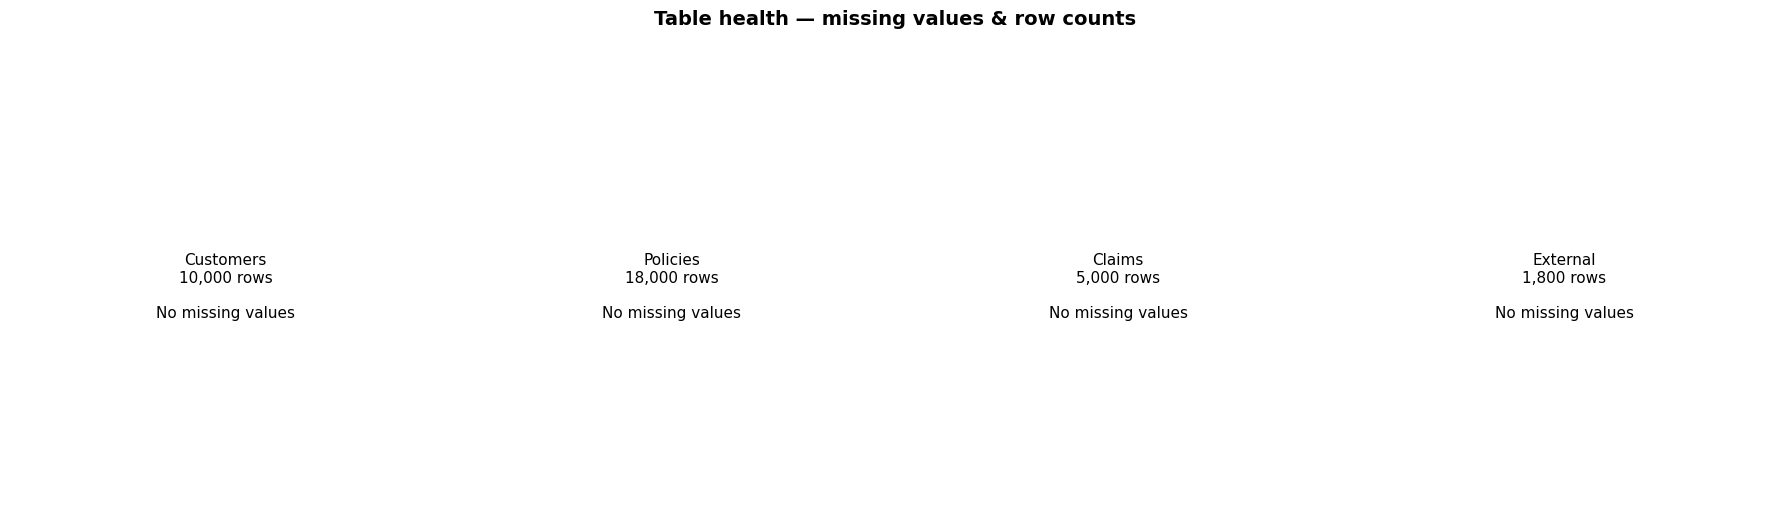

Integrity: orphan policies=0, orphan claims=0
Duplicates: customers=0, policies=0, claims=0


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Table health — missing values & row counts', fontsize=14, fontweight='bold', y=1.02)

for ax, (name, df) in zip(axes, [('Customers', customers), ('Policies', policies),
                                   ('Claims', claims), ('External', external)]):
    missing_pct = df.isnull().mean() * 100
    missing_pct = missing_pct[missing_pct > 0]
    if missing_pct.empty:
        ax.text(0.5, 0.5, f'{name}\n{len(df):,} rows\n\nNo missing values',
                ha='center', va='center', fontsize=11, transform=ax.transAxes)
        ax.set_axis_off()
    else:
        missing_pct.sort_values().plot(kind='barh', ax=ax, color='#2563eb', alpha=0.8)
        ax.set_title(f'{name} ({len(df):,} rows)')
        ax.set_xlabel('% missing')
        for bar, val in zip(ax.patches, missing_pct.sort_values()):
            ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

orphan_policies = (~policies['customer_id'].isin(customers['customer_id'])).sum()
orphan_claims   = (~claims['policy_id'].isin(policies['policy_id'])).sum()
dup_customers   = customers['customer_id'].duplicated().sum()
dup_policies    = policies['policy_id'].duplicated().sum()
dup_claims      = claims['claim_id'].duplicated().sum()

print(f"Integrity: orphan policies={orphan_policies}, orphan claims={orphan_claims}")
print(f"Duplicates: customers={dup_customers}, policies={dup_policies}, claims={dup_claims}")

## Fig 2 — Target 1: Claim Frequency Distribution & Dispersion

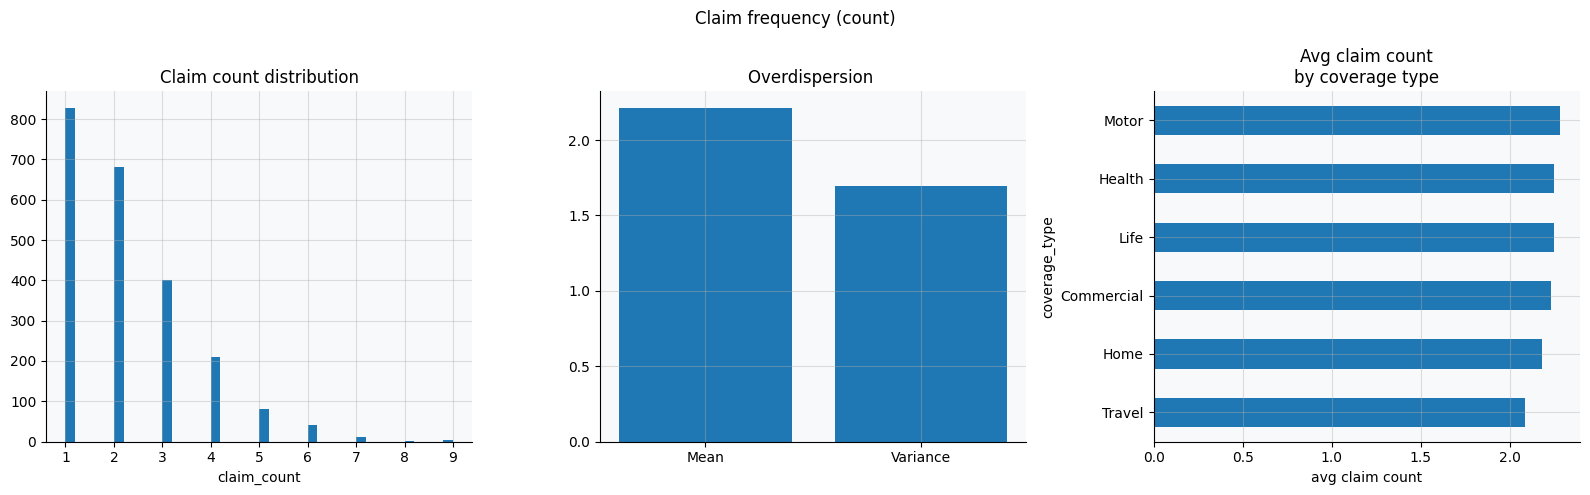

Dispersion ratio: 0.77 → Poisson may be sufficient


In [6]:
claims_enriched = claims.merge(customers[['customer_id', 'region']], on='customer_id', how='left')

df_freq = (claims_enriched.groupby(['coverage_type', 'region', 'year_month'])
           .size().reset_index(name='claim_count'))

mean_c = df_freq['claim_count'].mean()
var_c  = df_freq['claim_count'].var()
disp   = var_c / mean_c

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Claim frequency (count)')

df_freq['claim_count'].hist(bins=40, ax=axes[0])
axes[0].set_title(f'Claim count distribution')
axes[0].set_xlabel('claim_count')

axes[1].bar(['Mean', 'Variance'], [mean_c, var_c])
axes[1].set_title('Overdispersion ')

df_freq.groupby('coverage_type')['claim_count'].mean().sort_values().plot(
    kind='barh', ax=axes[2])
axes[2].set_title('Avg claim count\nby coverage type')
axes[2].set_xlabel('avg claim count')

plt.tight_layout()
plt.show()
print(f"Dispersion ratio: {disp:.2f} → {'Negative Binomial recommended' if disp > 2 else 'Poisson may be sufficient'}")

## Fig 3 — Target 2: Claim Severity Distribution

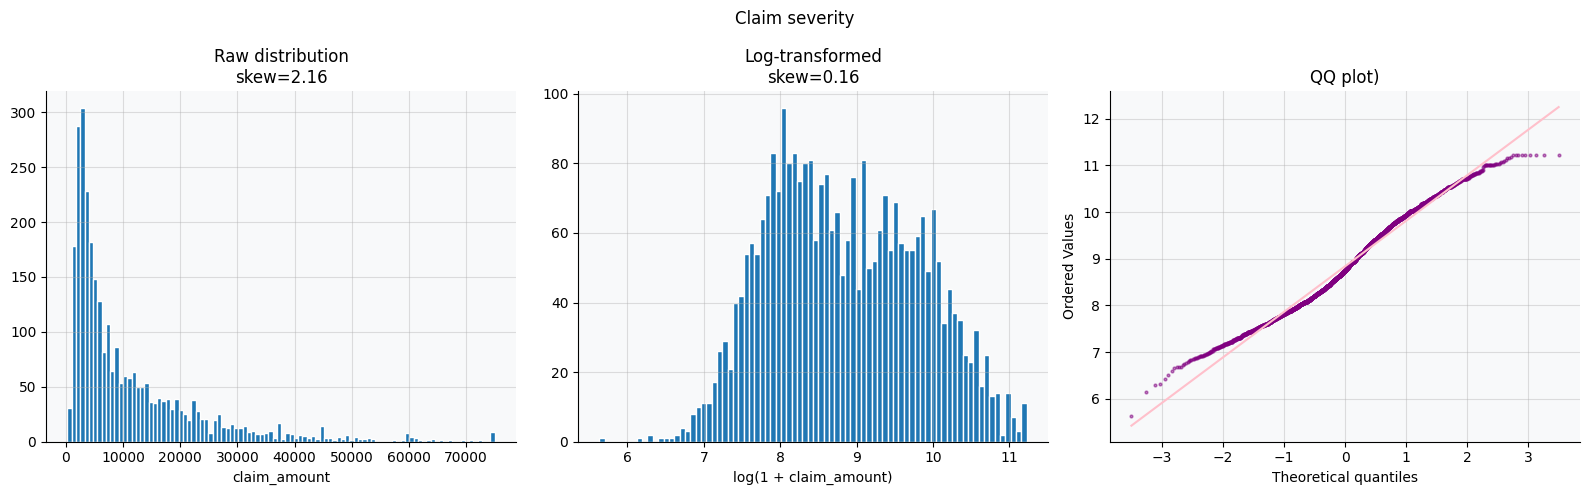

In [ ]:
settled = claims[claims['claim_status'] == 'Settled'].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Claim severity')

settled['claim_amount'].hist(bins=100, ax=axes[0], edgecolor='white')
axes[0].set_title(f'Raw distribution\nskew={settled["claim_amount"].skew():.2f}')
axes[0].set_xlabel('claim_amount')

log_skew = np.log1p(settled['claim_amount']).skew()
np.log1p(settled['claim_amount']).hist(bins=80, ax=axes[1], edgecolor='white')
axes[1].set_title(f'Log-transformed\nskew={log_skew:.2f}')
axes[1].set_xlabel('log(1 + claim_amount)')

stats.probplot(np.log1p(settled['claim_amount']), plot=axes[2])
axes[2].set_title('QQ plot')
axes[2].get_lines()[0].set(color='purple', alpha=0.5, markersize=2)
axes[2].get_lines()[1].set(color='pink', linewidth=1.5)

plt.tight_layout()
plt.show()


## Fig 4 — Severity by Claim Type

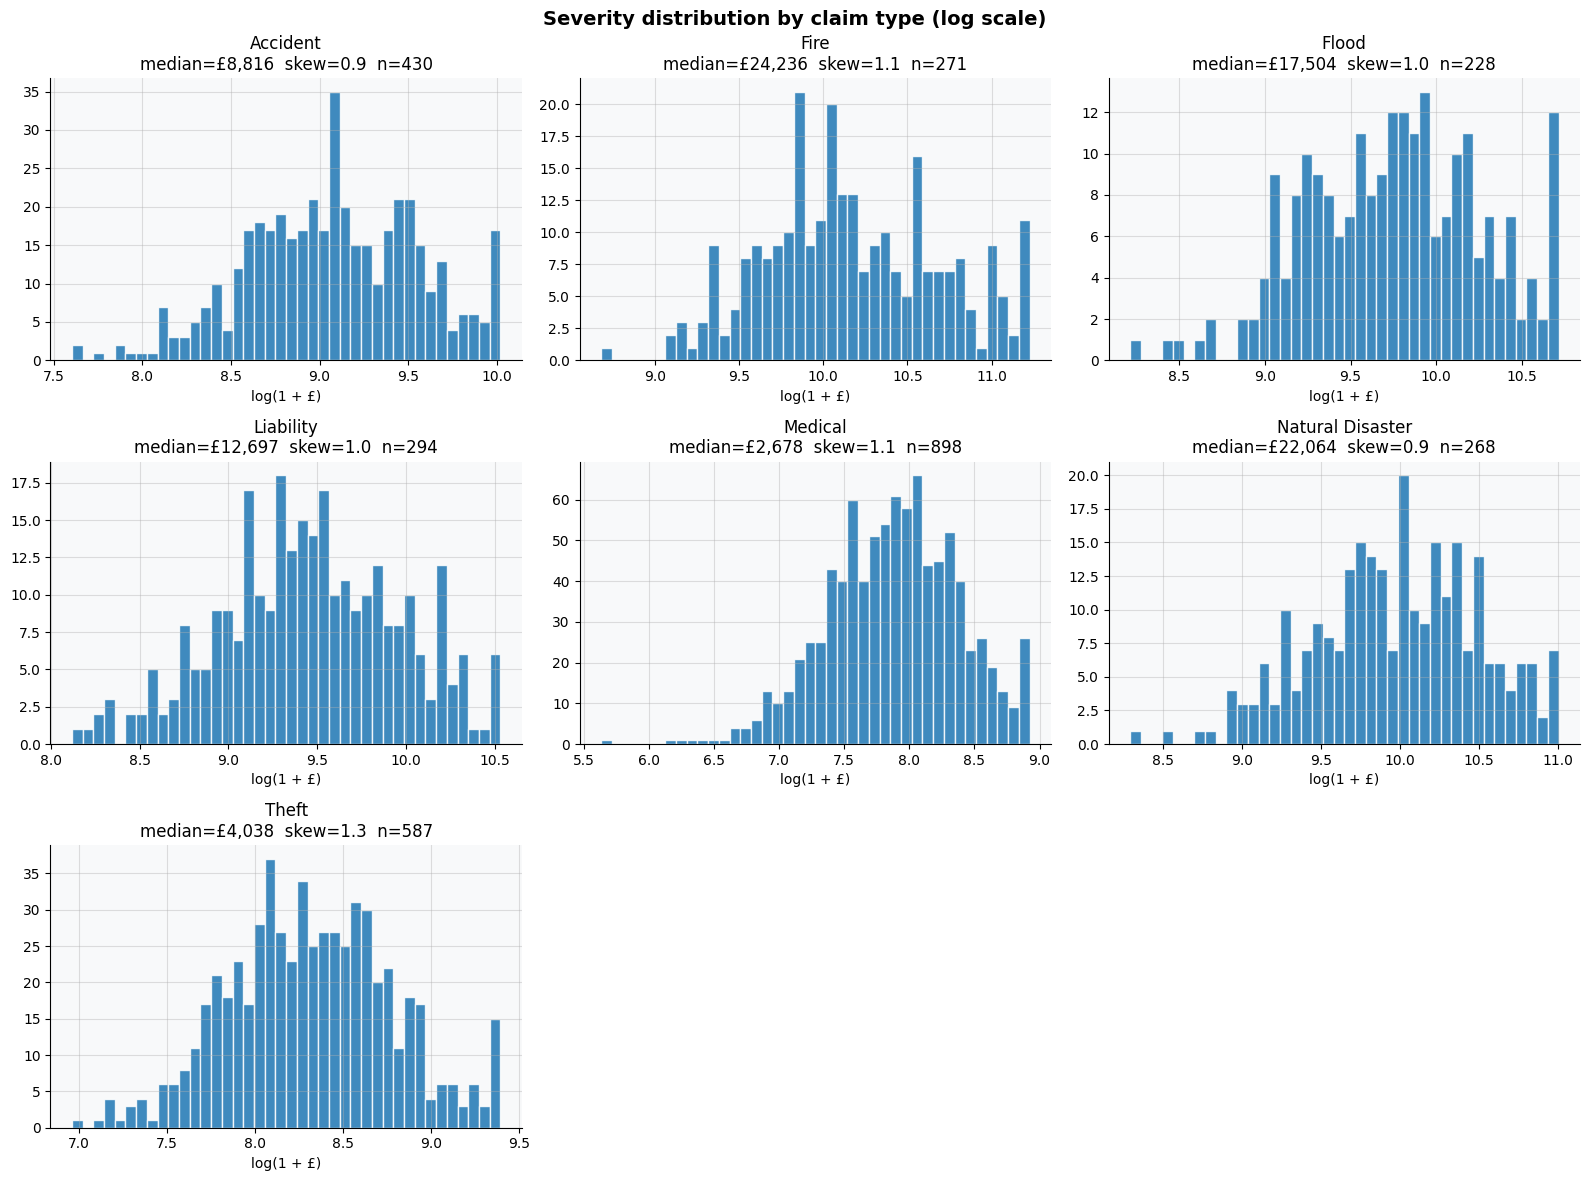

In [12]:
claim_types = settled['claim_type'].unique()
n = len(claim_types)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
fig.suptitle('Severity distribution by claim type (log scale)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, ct in enumerate(sorted(claim_types)):
    subset = settled[settled['claim_type'] == ct]['claim_amount']
    np.log1p(subset).hist(bins=40, ax=axes[i],alpha=0.85, edgecolor='white')
    axes[i].set_title(f'{ct}\nmedian=£{subset.median():,.0f}  skew={subset.skew():.1f}  n={len(subset):,}')
    axes[i].set_xlabel('log(1 + £)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Fig 5 — Time Series: Claims Over Time with Storm Overlay

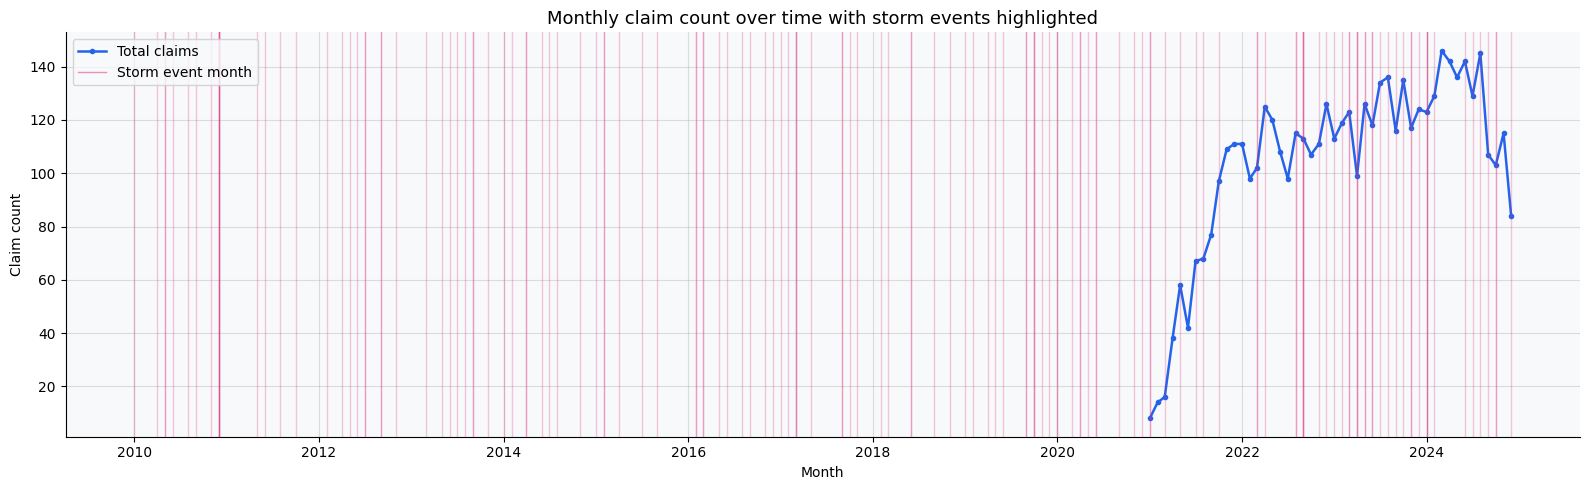

In [7]:
monthly = claims.groupby('year_month').size().reset_index(name='claim_count')
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

storm_months = external[external['storm_event_flag'] == 1]['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly['year_month_dt'], monthly['claim_count'],
        color='#2563eb', linewidth=1.8, marker='o', markersize=3, label='Total claims')

for m in storm_months:
    ax.axvline(x=m, color='#db2777', alpha=0.25, linewidth=1)
ax.axvline(x=storm_months.iloc[0], color='#db2777', alpha=0.5, linewidth=1, label='Storm event month')

ax.set_title('Monthly claim count over time with storm events highlighted', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Claim count')
ax.legend()
plt.tight_layout()
plt.show()

## Fig 6 — Key Predictor Relationships

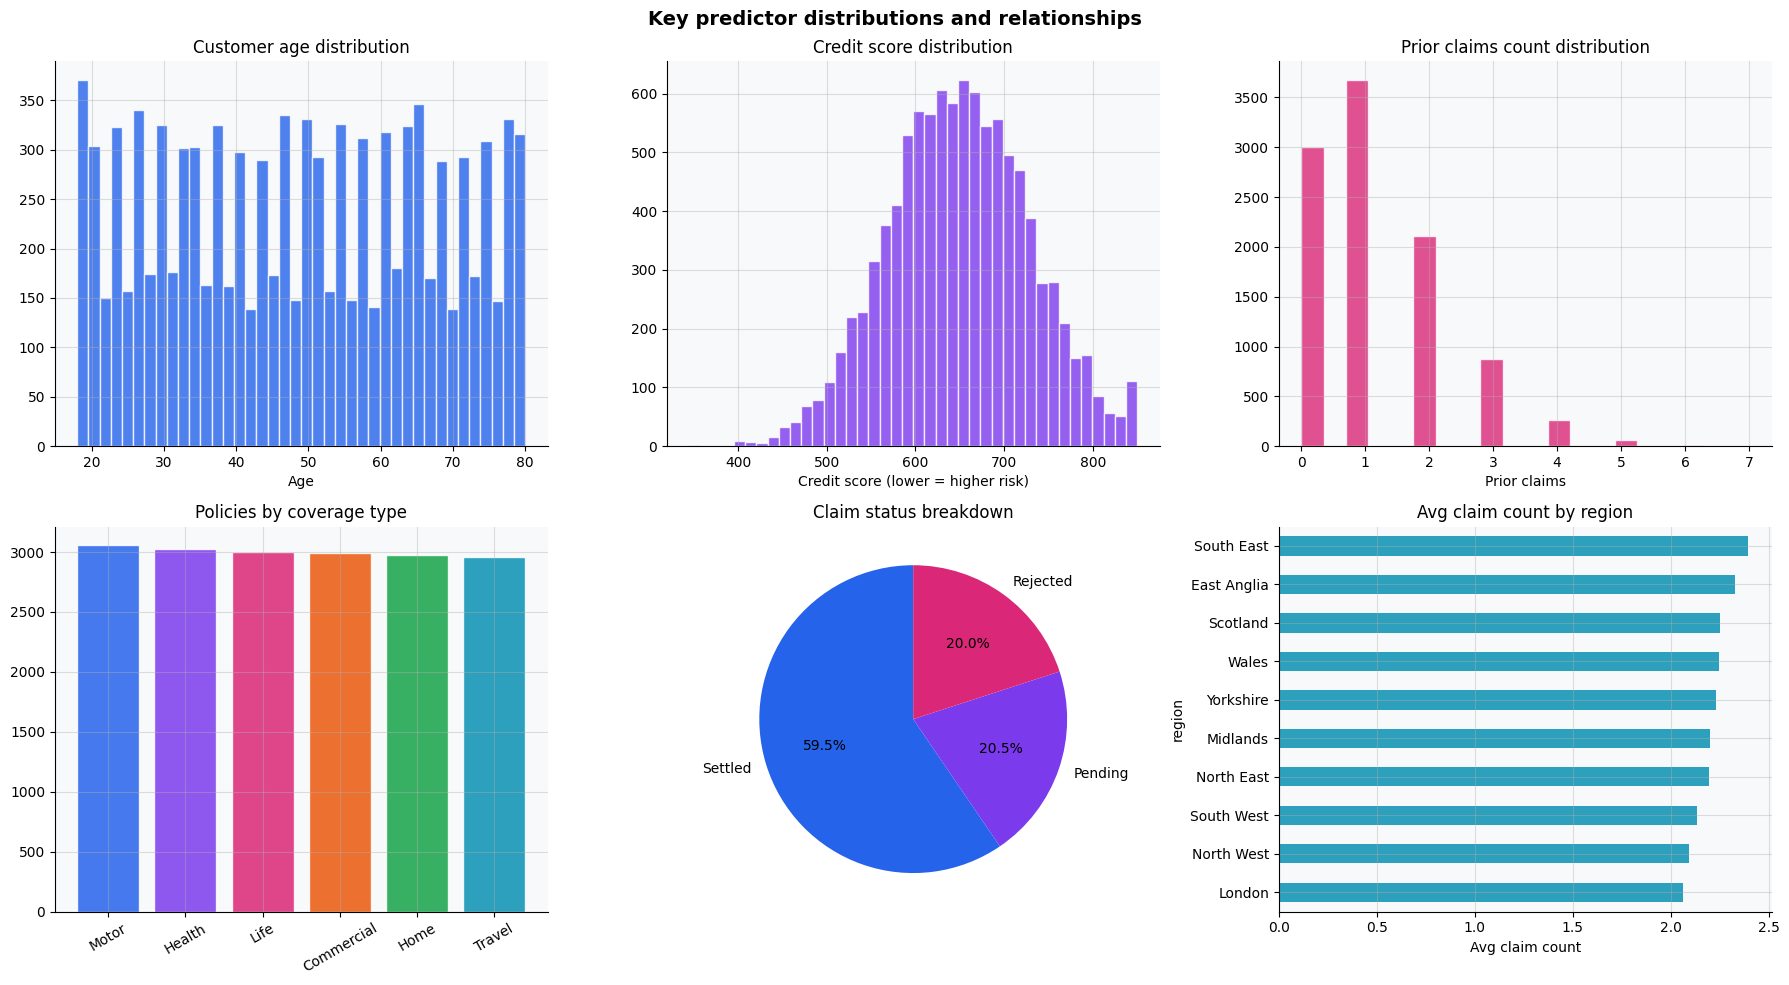

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key predictor distributions and relationships', fontsize=14, fontweight='bold')

customers['age'].hist(bins=40, ax=axes[0, 0], color='#2563eb', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Customer age distribution')
axes[0, 0].set_xlabel('Age')

customers['credit_score'].hist(bins=40, ax=axes[0, 1], color='#7c3aed', alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Credit score distribution')
axes[0, 1].set_xlabel('Credit score (lower = higher risk)')

customers['prior_claims_count'].hist(bins=20, ax=axes[0, 2], color='#db2777', alpha=0.8, edgecolor='white')
axes[0, 2].set_title('Prior claims count distribution')
axes[0, 2].set_xlabel('Prior claims')

cov_counts = policies['coverage_type'].value_counts()
axes[1, 0].bar(cov_counts.index, cov_counts.values, color=PALETTE[:len(cov_counts)], alpha=0.85, edgecolor='white')
axes[1, 0].set_title('Policies by coverage type')
axes[1, 0].tick_params(axis='x', rotation=30)

cs = claims['claim_status'].value_counts()
axes[1, 1].pie(cs.values, labels=cs.index, autopct='%1.1f%%', colors=PALETTE[:len(cs)], startangle=90)
axes[1, 1].set_title('Claim status breakdown')

region_freq = df_freq.groupby('region')['claim_count'].mean().sort_values()
region_freq.plot(kind='barh', ax=axes[1, 2], color='#0891b2', alpha=0.85)
axes[1, 2].set_title('Avg claim count by region')
axes[1, 2].set_xlabel('Avg claim count')

plt.tight_layout()
plt.show()

## Fig 7 — Correlation Heatmaps

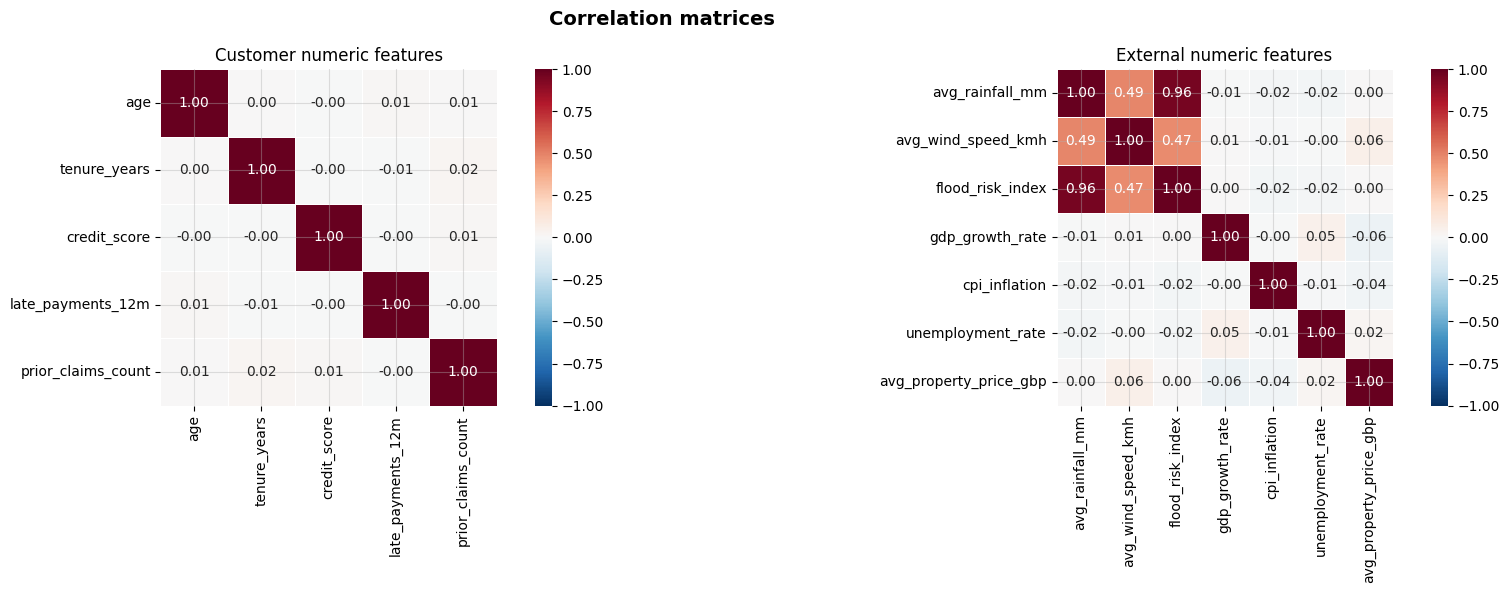

High correlations (|r| > 0.7):
  avg_rainfall_mm vs flood_risk_index: r=0.96


In [9]:
numeric_cols = ['age', 'tenure_years', 'credit_score', 'late_payments_12m', 'prior_claims_count']
ext_cols     = ['avg_rainfall_mm', 'avg_wind_speed_kmh', 'flood_risk_index',
                'gdp_growth_rate', 'cpi_inflation', 'unemployment_rate', 'avg_property_price_gbp']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Correlation matrices', fontsize=14, fontweight='bold')

corr_cust = customers[numeric_cols].corr()
sns.heatmap(corr_cust, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True, linewidths=0.5, linecolor='white')
axes[0].set_title('Customer numeric features')

corr_ext = external[ext_cols].corr()
sns.heatmap(corr_ext, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[1], square=True, linewidths=0.5, linecolor='white')
axes[1].set_title('External numeric features')

plt.tight_layout()
plt.show()

high = (corr_ext.abs() > 0.7) & (corr_ext != 1.0)
pairs = [(corr_ext.index[i], corr_ext.columns[j], corr_ext.iloc[i, j])
         for i in range(len(corr_ext)) for j in range(i+1, len(corr_ext))
         if high.iloc[i, j]]
print("High correlations (|r| > 0.7):")
for a, b, r in pairs:
    print(f"  {a} vs {b}: r={r:.2f}")

## Fig 8 — Claims Filter Funnel & Quality

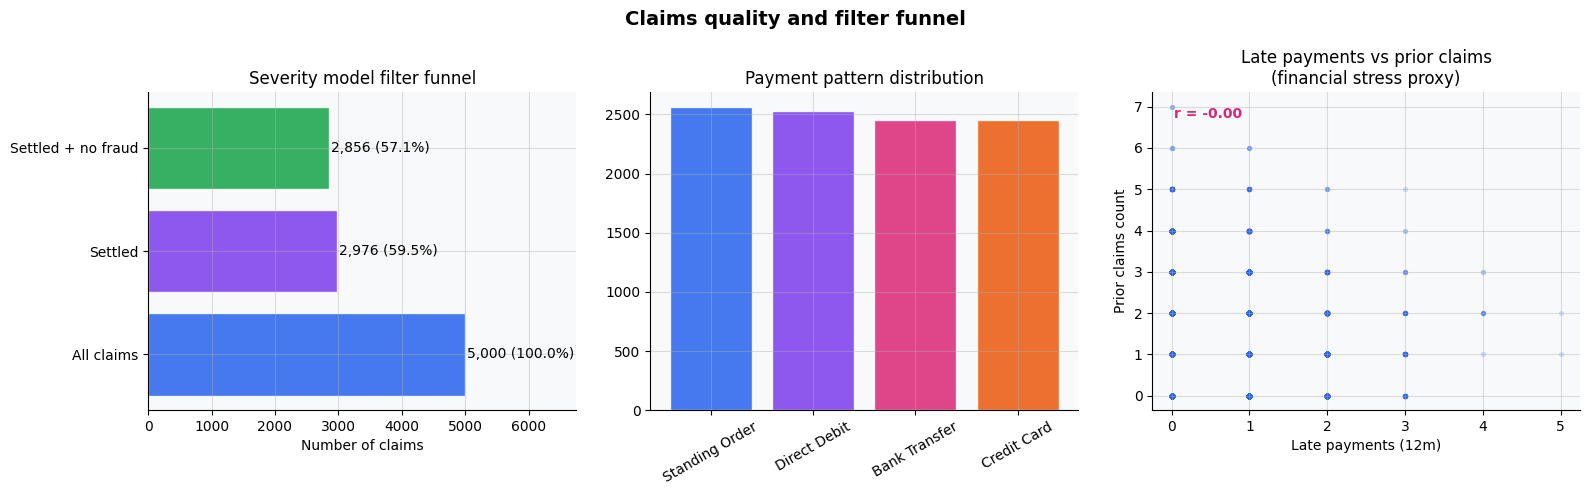

Total: 5,000  |  Settled: 2,976 (59.5%)  |  Settled+clean: 2,856 (57.1%)  |  Fraud: 190 (3.8%)


In [10]:
total     = len(claims)
settled_n = (claims['claim_status'] == 'Settled').sum()
clean_n   = ((claims['claim_status'] == 'Settled') & (claims['fraud_flag'] == 0)).sum()
fraud_n   = claims['fraud_flag'].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Claims quality and filter funnel', fontsize=14, fontweight='bold')

labels = ['All claims', 'Settled', 'Settled + no fraud']
values = [total, settled_n, clean_n]
colors = ['#2563eb', '#7c3aed', '#16a34a']
bars = axes[0].barh(labels, values, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({val/total*100:.1f}%)', va='center', fontsize=10)
axes[0].set_title('Severity model filter funnel')
axes[0].set_xlabel('Number of claims')
axes[0].set_xlim(0, total * 1.35)

pp = customers['payment_pattern'].value_counts()
axes[1].bar(pp.index, pp.values, color=PALETTE[:len(pp)], alpha=0.85, edgecolor='white')
axes[1].set_title('Payment pattern distribution')
axes[1].tick_params(axis='x', rotation=30)

axes[2].scatter(customers['late_payments_12m'], customers['prior_claims_count'],
                alpha=0.15, s=8, color='#2563eb')
axes[2].set_xlabel('Late payments (12m)')
axes[2].set_ylabel('Prior claims count')
axes[2].set_title('Late payments vs prior claims\n(financial stress proxy)')
corr_val = customers[['late_payments_12m', 'prior_claims_count']].corr().iloc[0, 1]
axes[2].text(0.05, 0.92, f'r = {corr_val:.2f}', transform=axes[2].transAxes,
             fontsize=10, color='#db2777', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total: {total:,}  |  Settled: {settled_n:,} ({settled_n/total*100:.1f}%)  "
      f"|  Settled+clean: {clean_n:,} ({clean_n/total*100:.1f}%)  |  Fraud: {fraud_n:,} ({fraud_n/total*100:.1f}%)")

## Fig 9 — External Data Validation

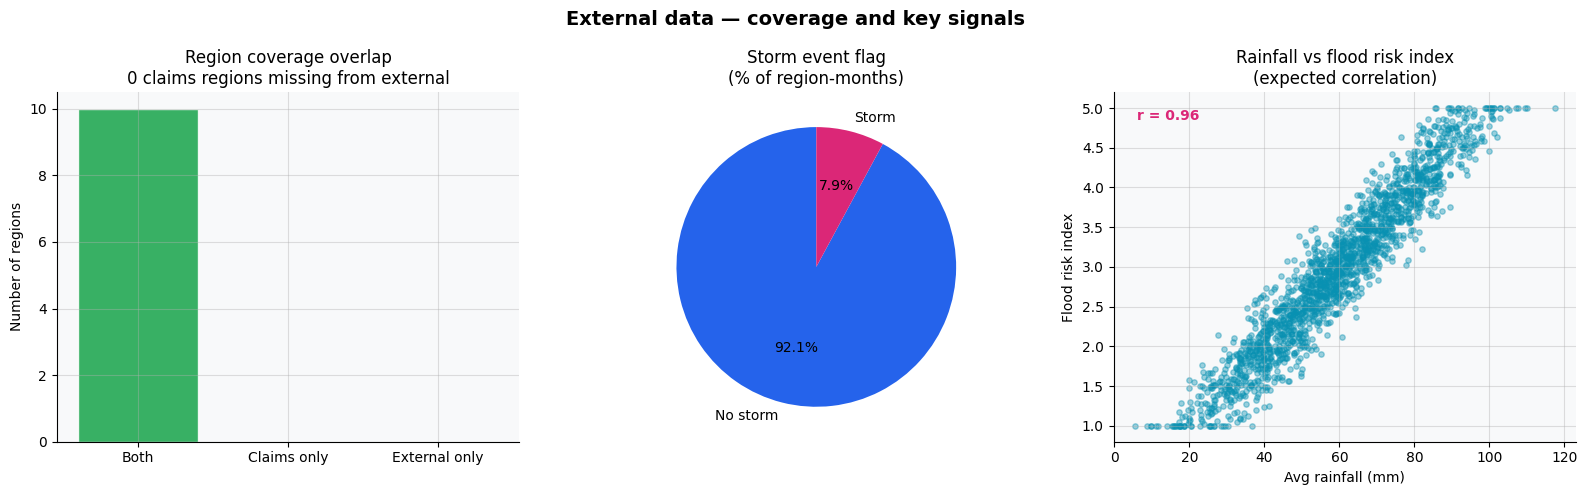

Regions in claims not in external: set()
Rainfall vs flood risk correlation: 0.96


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('External data — coverage and key signals', fontsize=14, fontweight='bold')

claims_regions   = set(customers['region'].str.strip().str.lower())
external_regions = set(external['region'].str.strip().str.lower())
in_both      = claims_regions & external_regions
only_claims  = claims_regions - external_regions
only_ext     = external_regions - claims_regions

axes[0].bar(['Both', 'Claims only', 'External only'],
            [len(in_both), len(only_claims), len(only_ext)],
            color=['#16a34a', '#db2777', '#ea580c'], alpha=0.85, edgecolor='white')
axes[0].set_title(f'Region coverage overlap\n{len(only_claims)} claims regions missing from external')
axes[0].set_ylabel('Number of regions')

storm_dist = external['storm_event_flag'].value_counts()
axes[1].pie(storm_dist.values, labels=['No storm', 'Storm'],
            autopct='%1.1f%%', colors=['#2563eb', '#db2777'], startangle=90)
axes[1].set_title('Storm event flag\n(% of region-months)')

axes[2].scatter(external['avg_rainfall_mm'], external['flood_risk_index'],
                alpha=0.4, s=15, color='#0891b2')
axes[2].set_xlabel('Avg rainfall (mm)')
axes[2].set_ylabel('Flood risk index')
axes[2].set_title('Rainfall vs flood risk index\n(expected correlation)')
r_val = external[['avg_rainfall_mm', 'flood_risk_index']].corr().iloc[0, 1]
axes[2].text(0.05, 0.92, f'r = {r_val:.2f}', transform=axes[2].transAxes,
             fontsize=10, color='#db2777', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Regions in claims not in external: {only_claims}")
print(f"Rainfall vs flood risk correlation: {r_val:.2f}")

## Key Findings Summary

In [12]:
print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"\n[Frequency] Dispersion ratio: {disp:.2f}")
print(f"  → {'Negative Binomial recommended' if disp > 2 else 'Poisson may be sufficient'}")
print(f"\n[Severity] Raw skew={claims['claim_amount'].skew():.2f}, log skew={log_skew:.2f}")
print(f"  → {'Log-normal confirmed — use Gamma GLM or log-transform' if abs(log_skew) < 1 else 'Moderate log skew — check per claim type'}")
print(f"\n[Claims filter]")
print(f"  Total:           {total:,}")
print(f"  Settled:         {settled_n:,} ({settled_n/total*100:.1f}%)")
print(f"  Settled+clean:   {clean_n:,} ({clean_n/total*100:.1f}%)")
print(f"  Fraud:           {fraud_n:,} ({fraud_n/total*100:.1f}%)")

KEY FINDINGS SUMMARY

[Frequency] Dispersion ratio: 0.77
  → Poisson may be sufficient

[Severity] Raw skew=2.11, log skew=0.16
  → Log-normal confirmed — use Gamma GLM or log-transform

[Claims filter]
  Total:           5,000
  Settled:         2,976 (59.5%)
  Settled+clean:   2,856 (57.1%)
  Fraud:           190 (3.8%)


---

# Target 1 — Claim Frequency Prediction

Dispersion ratio < 1 (underdispersed) → **Poisson GLM** is appropriate.  
We model `claim_count` per `(coverage_type, region, year_month)` using customer, policy, and external features.

## 1. Build Modelling Dataset

In [13]:
# ── Occupation bucketing (free-text → risk tier) ────────────────────────────
def bucket_occupation(occ):
    occ = str(occ).lower()
    if any(x in occ for x in ['doctor', 'lawyer', 'engineer', 'accountant', 'manager',
                                'director', 'analyst', 'consultant', 'architect', 'nurse']):
        return 'Professional'
    elif any(x in occ for x in ['driver', 'builder', 'plumber', 'electrician', 'mechanic',
                                  'construction', 'manual', 'factory', 'warehouse', 'delivery']):
        return 'Trade'
    elif any(x in occ for x in ['retired', 'pensioner']):
        return 'Retired'
    elif 'student' in occ:
        return 'Student'
    else:
        return 'Other'

customers['occ_bucket'] = customers['occupation'].apply(bucket_occupation)

# ── Customer features aggregated to region level ─────────────────────────────
cust_region = customers.groupby('region').agg(
    avg_age              =('age',                'mean'),
    avg_credit_score     =('credit_score',       'mean'),
    avg_prior_claims     =('prior_claims_count', 'mean'),
    avg_late_payments    =('late_payments_12m',  'mean'),
    avg_tenure           =('tenure_years',       'mean'),
    pct_female           =('gender',          lambda x: (x == 'F').mean()),
    pct_high_income      =('income_band',     lambda x: x.isin(['>100k', '60-100k']).mean()),
    pct_direct_debit     =('payment_pattern', lambda x: (x == 'Direct Debit').mean()),
    pct_professional     =('occ_bucket',      lambda x: (x == 'Professional').mean()),
    pct_trade            =('occ_bucket',      lambda x: (x == 'Trade').mean()),
).reset_index()

# ── Policy features aggregated to coverage_type level ───────────────────────
pol_cov = policies.groupby('coverage_type').agg(
    policy_count       =('policy_id',            'count'),
    avg_annual_premium =('annual_premium',        'mean'),
    avg_sum_insured    =('sum_insured',           'mean'),
    avg_excess         =('excess_amount',         'mean'),
    avg_renewal_count  =('renewal_count',         'mean'),
    pct_active         =('policy_status',         lambda x: (x == 'Active').mean()),
    pct_broker         =('distribution_channel',  lambda x: (x == 'Broker').mean()),
    pct_aggregator     =('distribution_channel',  lambda x: (x == 'Aggregator').mean()),
).reset_index()

# ── External per (region, year_month) ───────────────────────────────────────
ext_agg = external.groupby(['region', 'year_month']).agg(
    avg_rainfall_mm        =('avg_rainfall_mm',        'mean'),
    avg_wind_speed_kmh     =('avg_wind_speed_kmh',     'mean'),
    flood_risk_index       =('flood_risk_index',       'mean'),
    storm_event_flag       =('storm_event_flag',       'max'),
    gdp_growth_rate        =('gdp_growth_rate',        'mean'),
    cpi_inflation          =('cpi_inflation',          'mean'),
    unemployment_rate      =('unemployment_rate',      'mean'),
    avg_property_price_gbp =('avg_property_price_gbp', 'mean'),
).reset_index()

# ── Assemble ─────────────────────────────────────────────────────────────────
model_df = (df_freq
    .merge(cust_region, on='region',          how='left')
    .merge(pol_cov,     on='coverage_type',   how='left')
    .merge(ext_agg,     on=['region', 'year_month'], how='left')
)

# ── Interaction terms ────────────────────────────────────────────────────────
model_df['storm_x_flood']      = model_df['storm_event_flag']   * model_df['flood_risk_index']
model_df['storm_x_rainfall']   = model_df['storm_event_flag']   * model_df['avg_rainfall_mm']
model_df['rain_x_flood']       = model_df['avg_rainfall_mm']    * model_df['flood_risk_index']
model_df['credit_x_prior']     = model_df['avg_credit_score']   * model_df['avg_prior_claims']
model_df['late_x_prior']       = model_df['avg_late_payments']  * model_df['avg_prior_claims']
model_df['premium_x_excess']   = model_df['avg_annual_premium'] * model_df['avg_excess']
model_df['insured_x_inflation'] = model_df['avg_sum_insured']   * model_df['cpi_inflation']

# ── Encode categoricals ───────────────────────────────────────────────────────
model_df = pd.get_dummies(model_df, columns=['coverage_type', 'region'], drop_first=True)
model_df['year_month_int'] = model_df['year_month'].dt.year * 12 + model_df['year_month'].dt.month
model_df['month']          = model_df['year_month'].dt.month
model_df = model_df.drop(columns=['year_month'])

print(f"Modelling dataset: {model_df.shape[0]} rows × {model_df.shape[1]} columns")
print(f"Target mean={model_df['claim_count'].mean():.2f}, max={model_df['claim_count'].max()}")
model_df.head(3)

Modelling dataset: 2258 rows × 50 columns
Target mean=2.21, max=9


,claim_count,avg_age,avg_credit_score,avg_prior_claims,avg_late_payments,avg_tenure,pct_female,pct_high_income,pct_direct_debit,pct_professional,...,region_Midlands,region_North East,region_North West,region_Scotland,region_South East,region_South West,region_Wales,region_Yorkshire,year_month_int,month
0,1,48.400585,651.037037,1.205653,0.402534,7.869396,0.31384,0.390838,0.259259,0.241715,...,False,False,False,False,False,False,False,False,24254,2
1,2,48.400585,651.037037,1.205653,0.402534,7.869396,0.31384,0.390838,0.259259,0.241715,...,False,False,False,False,False,False,False,False,24256,4
2,1,48.400585,651.037037,1.205653,0.402534,7.869396,0.31384,0.390838,0.259259,0.241715,...,False,False,False,False,False,False,False,False,24259,7


## 2. Train / Test Split

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TARGET   = 'claim_count'
FEATURES = [c for c in model_df.columns if c != TARGET]

model_df_clean = model_df[FEATURES + [TARGET]].dropna()

X_raw = model_df_clean[FEATURES].astype(float)
y     = model_df_clean[TARGET]

# Scale continuous features so regularisation is applied evenly
bool_cols = [c for c in FEATURES if set(X_raw[c].unique()).issubset({0, 1, True, False})]
cont_cols  = [c for c in FEATURES if c not in bool_cols]

scaler  = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[cont_cols] = scaler.fit_transform(X_raw[cont_cols])

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}  |  Features: {len(FEATURES)}")

Train: 1,806  |  Test: 452  |  Features: 49


## 3. Poisson GLM (statsmodels)

In [15]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Step 1: fit full model to get p-values
glm_full = sm.GLM(y_train, sm.add_constant(X_train),
                  family=sm.families.Poisson()).fit()

# Step 2: keep only statistically significant features (p < 0.05), excluding the constant
sig_features = [f for f in glm_full.pvalues.index
                if f != 'const' and glm_full.pvalues[f] < 0.05]

print(f"Features selected: {len(sig_features)} / {len(FEATURES)}")
print("Selected:", sig_features)

# Step 3: refit on selected features only with light L2 regularisation
X_train_sel = sm.add_constant(X_train[sig_features])
X_test_sel  = sm.add_constant(X_test[sig_features],  has_constant='add')
X_full_sel  = sm.add_constant(X_scaled[sig_features], has_constant='add')

glm = sm.GLM(y_train, X_train_sel,
             family=sm.families.Poisson()).fit_regularized(alpha=0.01, L1_wt=0.0)

y_pred_test = glm.predict(X_test_sel)
mae_test    = mean_absolute_error(y_test, y_pred_test)
rmse_test   = mean_squared_error(y_test, y_pred_test) ** 0.5
rel_test    = mae_test / y.mean() * 100

y_pred_full = glm.predict(X_full_sel)
mae_full    = mean_absolute_error(y, y_pred_full)
rel_full    = mae_full / y.mean() * 100

print(f"\nTest  MAE={mae_test:.3f}  RMSE={rmse_test:.3f}  Relative MAE={rel_test:.1f}%")
print(f"Full  MAE={mae_full:.3f}                        Relative MAE={rel_full:.1f}%")

Features selected: 15 / 49
Selected: ['coverage_type_Health', 'coverage_type_Home', 'coverage_type_Life', 'coverage_type_Motor', 'coverage_type_Travel', 'region_London', 'region_Midlands', 'region_North East', 'region_North West', 'region_Scotland', 'region_South East', 'region_South West', 'region_Wales', 'region_Yorkshire', 'year_month_int']

Test  MAE=0.948  RMSE=1.200  Relative MAE=42.8%
Full  MAE=1.002                        Relative MAE=45.2%


## 4. Actual vs Predicted Claims Over Time

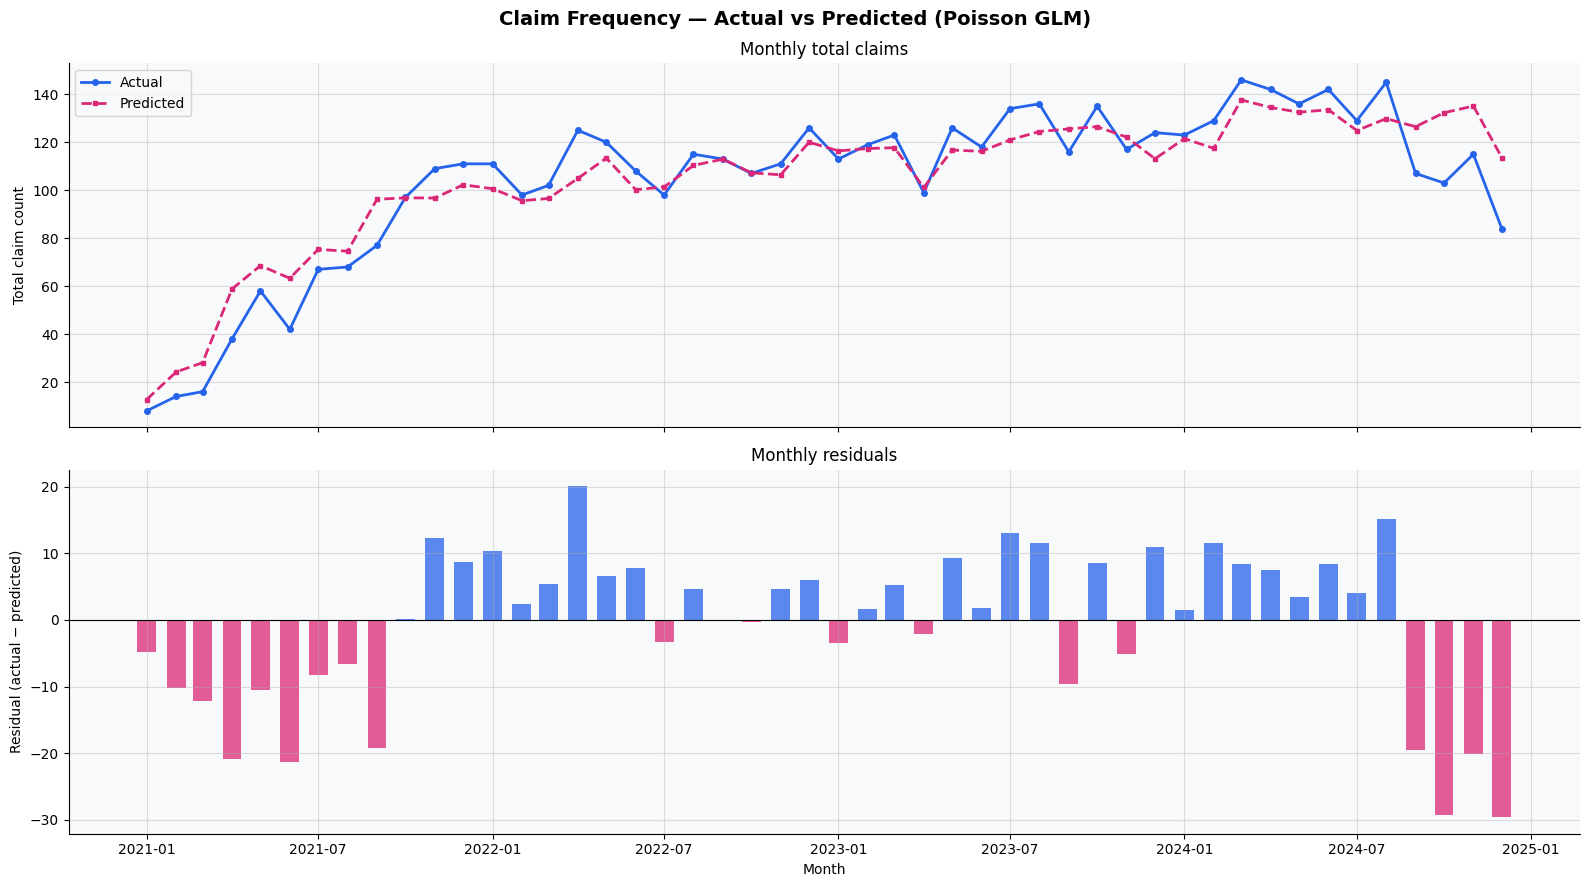

Full  MAE=1.002  Relative MAE=45.2%


In [16]:
results = model_df_clean[['year_month_int']].copy()
results['actual']    = y.values
results['predicted'] = y_pred_full.values

monthly_results = (results
    .groupby('year_month_int')[['actual', 'predicted']]
    .sum()
    .reset_index()
    .sort_values('year_month_int')
)

def int_to_timestamp(x):
    m = x % 12
    if m == 0:
        return pd.Timestamp(year=(x // 12) - 1, month=12, day=1)
    return pd.Timestamp(year=x // 12, month=m, day=1)

monthly_results['date'] = monthly_results['year_month_int'].apply(int_to_timestamp)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Claim Frequency — Actual vs Predicted (Poisson GLM)', fontsize=14, fontweight='bold')

axes[0].plot(monthly_results['date'], monthly_results['actual'],
             color='#2563eb', linewidth=2, marker='o', markersize=4, label='Actual')
axes[0].plot(monthly_results['date'], monthly_results['predicted'],
             color='#db2777', linewidth=2, linestyle='--', marker='s', markersize=3, label='Predicted')
axes[0].set_ylabel('Total claim count')
axes[0].legend()
axes[0].set_title('Monthly total claims')

monthly_results['residual'] = monthly_results['actual'] - monthly_results['predicted']
axes[1].bar(monthly_results['date'], monthly_results['residual'],
            color=monthly_results['residual'].apply(lambda x: '#2563eb' if x >= 0 else '#db2777'),
            alpha=0.75, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Residual (actual − predicted)')
axes[1].set_xlabel('Month')
axes[1].set_title('Monthly residuals')

plt.tight_layout()
plt.show()

print(f"Full  MAE={mae_full:.3f}  Relative MAE={rel_full:.1f}%")

## 5. Predictions Table

In [17]:
# Rebuild original labels from df_freq for readability
pred_table = df_freq.copy()
pred_table = pred_table[pred_table.index.isin(model_df_clean.index)]
pred_table['predicted'] = y_pred_full.round(2).values
pred_table['residual']  = (pred_table['claim_count'] - pred_table['predicted']).round(2)
pred_table['abs_error'] = pred_table['residual'].abs().round(2)

pred_table = pred_table.rename(columns={'claim_count': 'actual'})[
    ['coverage_type', 'region', 'year_month', 'actual', 'predicted', 'residual', 'abs_error']
].sort_values(['year_month', 'region', 'coverage_type']).reset_index(drop=True)

pred_table['year_month'] = pred_table['year_month'].astype(str)

print(f"Rows: {len(pred_table):,}   MAE={pred_table['abs_error'].mean():.3f}")
pred_table

Rows: 2,258   MAE=1.002


,coverage_type,region,year_month,actual,predicted,residual,abs_error
0,Commercial,Midlands,2021-01,1,1.84,-0.84,0.84
1,Commercial,North West,2021-01,1,1.78,-0.78,0.78
2,Home,Scotland,2021-01,1,1.77,-0.77,0.77
3,Travel,Scotland,2021-01,1,1.75,-0.75,0.75
4,Motor,South West,2021-01,1,1.83,-0.83,0.83
...,...,...,...,...,...,...,...
2253,Commercial,Yorkshire,2024-12,1,2.64,-1.64,1.64
2254,Health,Yorkshire,2024-12,2,2.69,-0.69,0.69
2255,Home,Yorkshire,2024-12,2,2.54,-0.54,0.54
2256,Life,Yorkshire,2024-12,1,2.79,-1.79,1.79


---

# Target 2 — Claim Severity Prediction

Model: **Gamma GLM with log link** (confirmed by EDA — log skew = 0.16).  
Modelled at **individual claim level** on settled, non-fraud claims only.

## 1. Build Severity Dataset

In [ ]:
# Filter: settled + non-fraud only
sev_base = claims[(claims['claim_status'] == 'Settled') & (claims['fraud_flag'] == 0)].copy()

# Get coverage_type + sum_insured from policies
sev_base = sev_base.drop(columns=['coverage_type'], errors='ignore')
sev_base = sev_base.merge(policies[['policy_id', 'coverage_type', 'sum_insured']], on='policy_id', how='left')
sev_base = sev_base.merge(customers[['customer_id', 'region']], on='customer_id', how='left')

# Aggregate to segment level
sev_seg = (sev_base
    .groupby(['coverage_type', 'region', 'year_month'])
    .agg(
        avg_severity        =('claim_amount',    'mean'),
        claim_count         =('claim_amount',    'count'),
        avg_settlement_days =('settlement_days', 'mean'),
        avg_sum_insured     =('sum_insured',     'mean'),
    )
    .reset_index()
)

# Join external features
sev_seg = sev_seg.merge(ext_agg, on=['region', 'year_month'], how='left')

# Join customer aggregates (region level)
sev_seg = sev_seg.merge(cust_region, on='region', how='left')

# Interaction terms
sev_seg['storm_x_flood']      = sev_seg['storm_event_flag']  * sev_seg['flood_risk_index']
sev_seg['storm_x_rainfall']   = sev_seg['storm_event_flag']  * sev_seg['avg_rainfall_mm']
sev_seg['rain_x_flood']       = sev_seg['avg_rainfall_mm']   * sev_seg['flood_risk_index']
sev_seg['credit_x_prior']     = sev_seg['avg_credit_score']  * sev_seg['avg_prior_claims']
sev_seg['late_x_prior']       = sev_seg['avg_late_payments'] * sev_seg['avg_prior_claims']
sev_seg['insured_x_inflation'] = sev_seg['avg_sum_insured']  * sev_seg['cpi_inflation']

# Encode categoricals
sev_seg = pd.get_dummies(sev_seg, columns=['coverage_type', 'region'], drop_first=True)
sev_seg['year_month_int'] = sev_seg['year_month'].dt.year * 12 + sev_seg['year_month'].dt.month
sev_seg['month']          = sev_seg['year_month'].dt.month
sev_seg = sev_seg.drop(columns=['year_month'])

SEV_TARGET   = 'avg_severity'
SEV_FEATURES = [c for c in sev_seg.columns
                if c not in ['claim_count', SEV_TARGET]
                and sev_seg[c].dtype != 'object']

sev_clean = sev_seg[SEV_FEATURES + [SEV_TARGET]].dropna()

print(f"Severity dataset: {len(sev_clean):,} segments × {len(SEV_FEATURES)} features")
print(f"avg_severity  mean=£{sev_clean[SEV_TARGET].mean():,.0f}  "
      f"median=£{sev_clean[SEV_TARGET].median():,.0f}  "
      f"max=£{sev_clean[SEV_TARGET].max():,.0f}")
sev_clean.head(3)

## 2. Train / Test Split & Scale

In [19]:
X_sev = sev_clean[SEV_FEATURES].astype(float)
y_sev = sev_clean[SEV_TARGET]

sev_bool_cols = [c for c in SEV_FEATURES if set(X_sev[c].unique()).issubset({0, 1, True, False})]
sev_cont_cols = [c for c in SEV_FEATURES if c not in sev_bool_cols]

sev_scaler   = StandardScaler()
X_sev_scaled = X_sev.copy()
X_sev_scaled[sev_cont_cols] = sev_scaler.fit_transform(X_sev[sev_cont_cols])

X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(
    X_sev_scaled, y_sev, test_size=0.2, random_state=42
)

print(f"Train: {len(X_sev_train):,}  |  Test: {len(X_sev_test):,}  |  Features: {len(SEV_FEATURES)}")

Train: 1,375  |  Test: 344  |  Features: 41


## 3. Gamma GLM (log link) — no regularisation

In [20]:
# Step 1: fit full Gamma GLM to get p-values
glm_sev_full = sm.GLM(
    y_sev_train,
    sm.add_constant(X_sev_train),
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

# Step 2: keep only significant features (p < 0.05)
sev_sig_features = [f for f in glm_sev_full.pvalues.index
                    if f != 'const' and glm_sev_full.pvalues[f] < 0.05]

print(f"Features selected: {len(sev_sig_features)} / {len(SEV_FEATURES)}")
print("Selected:", sev_sig_features)

# Step 3: refit on selected features only
X_sev_train_sel = sm.add_constant(X_sev_train[sev_sig_features])
X_sev_test_sel  = sm.add_constant(X_sev_test[sev_sig_features],  has_constant='add')
X_sev_full_sel  = sm.add_constant(X_sev_scaled[sev_sig_features], has_constant='add')

glm_sev = sm.GLM(
    y_sev_train,
    X_sev_train_sel,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

y_sev_pred_test = glm_sev.predict(X_sev_test_sel)
y_sev_pred_full = glm_sev.predict(X_sev_full_sel)

mae_sev_test  = mean_absolute_error(y_sev_test, y_sev_pred_test)
rmse_sev_test = mean_squared_error(y_sev_test, y_sev_pred_test) ** 0.5
rel_sev_test  = mae_sev_test / y_sev.mean() * 100

mae_sev_full  = mean_absolute_error(y_sev, y_sev_pred_full)
rel_sev_full  = mae_sev_full / y_sev.mean() * 100

print(f"\nTest  MAE=£{mae_sev_test:,.0f}  RMSE=£{rmse_sev_test:,.0f}  Relative MAE={rel_sev_test:.1f}%")
print(f"Full  MAE=£{mae_sev_full:,.0f}                              Relative MAE={rel_sev_full:.1f}%")
print(f"\nMean avg_severity = £{y_sev.mean():,.0f}")

Features selected: 26 / 41
Selected: ['avg_age', 'avg_credit_score', 'avg_prior_claims', 'avg_late_payments', 'avg_tenure', 'pct_female', 'pct_high_income', 'pct_direct_debit', 'storm_x_flood', 'storm_x_rainfall', 'credit_x_prior', 'late_x_prior', 'coverage_type_Health', 'coverage_type_Home', 'coverage_type_Life', 'coverage_type_Motor', 'coverage_type_Travel', 'region_London', 'region_Midlands', 'region_North East', 'region_North West', 'region_Scotland', 'region_South East', 'region_South West', 'region_Wales', 'region_Yorkshire']

Test  MAE=£6,142  RMSE=£9,260  Relative MAE=54.6%
Full  MAE=£5,939                              Relative MAE=52.8%

Mean avg_severity = £11,249


## 4. Actual vs Predicted Severity Over Time

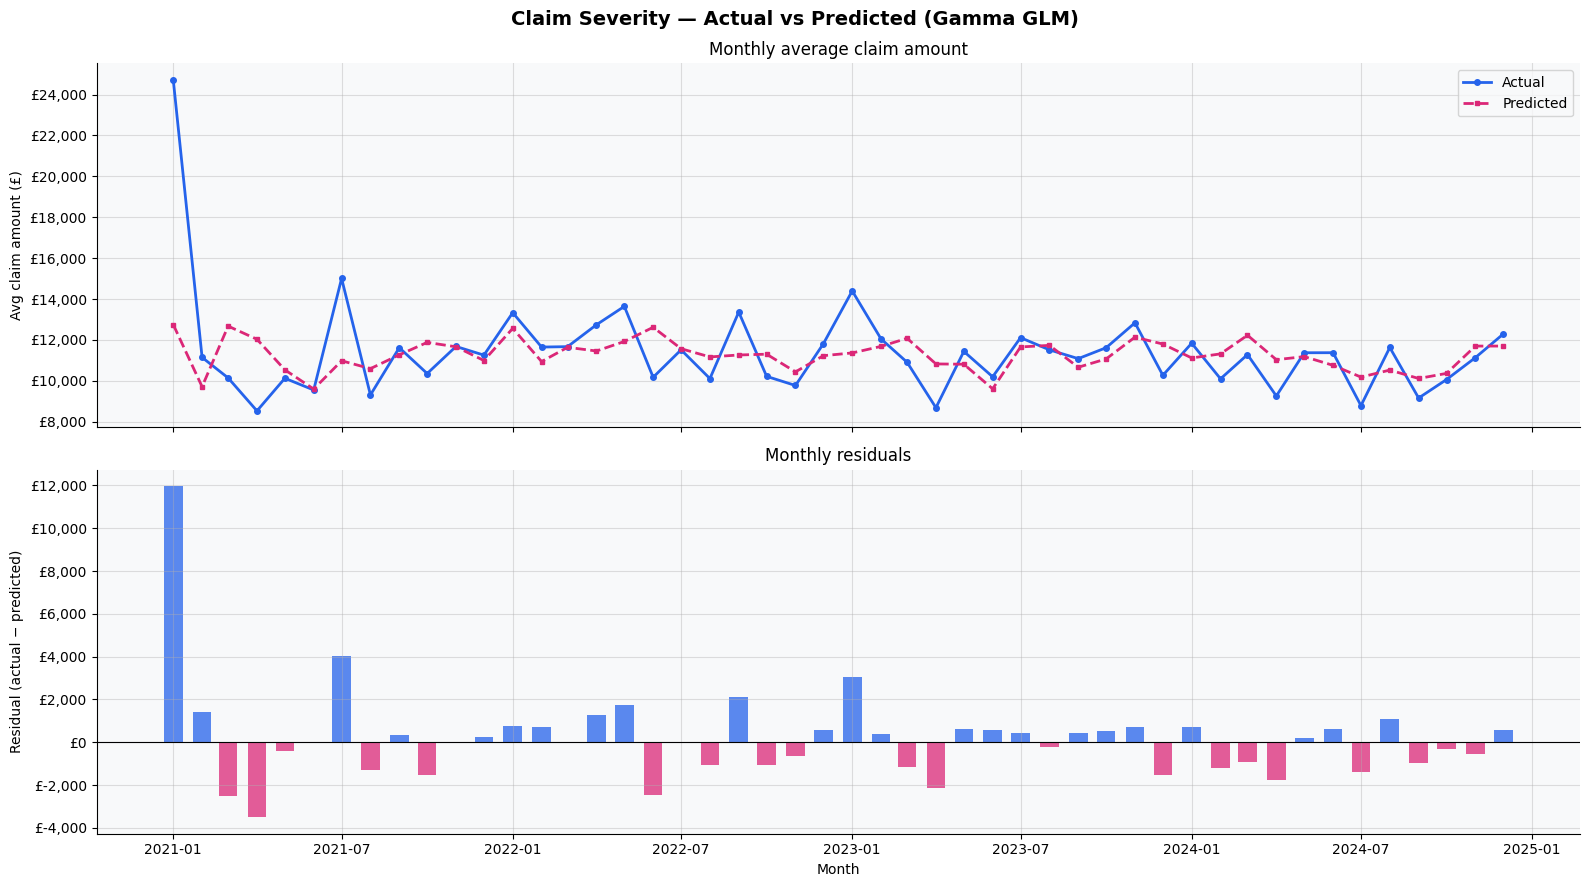

In [21]:
sev_results = sev_clean[['year_month_int']].copy()
sev_results['actual']    = y_sev.values
sev_results['predicted'] = y_sev_pred_full.values

monthly_sev = (sev_results
    .groupby('year_month_int')[['actual', 'predicted']]
    .mean()   # average claim amount per month
    .reset_index()
    .sort_values('year_month_int')
)
monthly_sev['date'] = monthly_sev['year_month_int'].apply(int_to_timestamp)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Claim Severity — Actual vs Predicted (Gamma GLM)', fontsize=14, fontweight='bold')

axes[0].plot(monthly_sev['date'], monthly_sev['actual'],
             color='#2563eb', linewidth=2, marker='o', markersize=4, label='Actual')
axes[0].plot(monthly_sev['date'], monthly_sev['predicted'],
             color='#db2777', linewidth=2, linestyle='--', marker='s', markersize=3, label='Predicted')
axes[0].set_ylabel('Avg claim amount (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].legend()
axes[0].set_title('Monthly average claim amount')

monthly_sev['residual'] = monthly_sev['actual'] - monthly_sev['predicted']
axes[1].bar(monthly_sev['date'], monthly_sev['residual'],
            color=monthly_sev['residual'].apply(lambda x: '#2563eb' if x >= 0 else '#db2777'),
            alpha=0.75, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].set_ylabel('Residual (actual − predicted)')
axes[1].set_xlabel('Month')
axes[1].set_title('Monthly residuals')

plt.tight_layout()
plt.show()

## 5. Severity Predictions Table

In [22]:
sev_table = (sev_base
    .groupby(['coverage_type', 'region', 'year_month'])
    .agg(actual=('claim_amount', 'mean'), n_claims=('claim_amount', 'count'))
    .reset_index()
)
sev_table = sev_table[sev_table.index.isin(sev_clean.index)].copy()
sev_table['predicted'] = y_sev_pred_full.round(2).values
sev_table['residual']  = (sev_table['actual'] - sev_table['predicted']).round(2)
sev_table['abs_error'] = sev_table['residual'].abs().round(2)
sev_table['year_month'] = sev_table['year_month'].astype(str)

sev_table = sev_table[
    ['coverage_type', 'region', 'year_month', 'n_claims', 'actual', 'predicted', 'residual', 'abs_error']
].sort_values(['year_month', 'region', 'coverage_type']).reset_index(drop=True)

print(f"Rows: {len(sev_table):,}   MAE=£{sev_table['abs_error'].mean():,.0f}   "
      f"Relative MAE={sev_table['abs_error'].mean()/sev_table['actual'].mean()*100:.1f}%")
sev_table

Rows: 1,719   MAE=£5,939   Relative MAE=52.8%


,coverage_type,region,year_month,n_claims,actual,predicted,residual,abs_error
0,Commercial,North West,2021-01,1,6488.000,16492.36,-10004.36,10004.36
1,Travel,Scotland,2021-01,1,48790.310,12316.72,36473.59,36473.59
2,Motor,South West,2021-01,1,18881.420,9448.84,9432.58,9432.58
3,Health,East Anglia,2021-02,1,3070.310,6414.57,-3344.26,3344.26
4,Motor,East Anglia,2021-02,1,22500.000,9798.80,12701.20,12701.20
...,...,...,...,...,...,...,...,...
1714,Motor,Wales,2024-12,5,10848.656,9473.32,1375.34,1375.34
1715,Health,Yorkshire,2024-12,1,13336.270,6779.01,6557.26,6557.26
1716,Home,Yorkshire,2024-12,1,4181.760,21454.49,-17272.73,17272.73
1717,Life,Yorkshire,2024-12,1,7500.000,3085.90,4414.10,4414.10


---

# Target 3 — Pure Premium

**Pure Premium = Frequency × Severity**

The expected £ cost per policy per month per segment.  
This is the standard actuarial pricing target — it tells underwriters what to charge.

```
pure_premium = predicted_claim_count × predicted_avg_severity
```

Exposure = number of active policies per `(coverage_type × region × month)`.

## 1. Build Pure Premium Dataset

In [23]:
# ── Exposure: active policies per (coverage_type, region, year_month) ────────
policy_cust = policies.merge(customers[['customer_id', 'region']], on='customer_id', how='left')

segments = df_freq[['coverage_type', 'region', 'year_month']].drop_duplicates().copy()
segments['month_start'] = segments['year_month'].dt.to_timestamp()
segments['month_end']   = segments['year_month'].dt.to_timestamp('M')

exposure_rows = []
for _, row in segments.iterrows():
    active = policy_cust[
        (policy_cust['coverage_type'] == row['coverage_type']) &
        (policy_cust['region']        == row['region']) &
        (policy_cust['start_date']    <= row['month_end']) &
        (policy_cust['end_date']      >= row['month_start'])
    ]
    exposure_rows.append({
        'coverage_type': row['coverage_type'],
        'region':        row['region'],
        'year_month':    row['year_month'],
        'exposure':      len(active),
    })

exposure = pd.DataFrame(exposure_rows)

# ── Actual pure premium: total claims cost / exposure ────────────────────────
# sev_base already has coverage_type and region — use it directly
total_cost = (sev_base
    .groupby(['coverage_type', 'region', 'year_month'])['claim_amount']
    .sum()
    .reset_index(name='total_claim_cost')
)

pp = (df_freq
    .rename(columns={'claim_count': 'actual_freq'})
    .merge(total_cost, on=['coverage_type', 'region', 'year_month'], how='left')
    .merge(exposure,   on=['coverage_type', 'region', 'year_month'], how='left')
)

pp['total_claim_cost']    = pp['total_claim_cost'].fillna(0)
pp['actual_pure_premium'] = pp['total_claim_cost'] / pp['exposure'].replace(0, np.nan)

print(f"Segments: {len(pp):,}")
print(f"Actual pure premium  mean=£{pp['actual_pure_premium'].mean():,.2f}  "
      f"median=£{pp['actual_pure_premium'].median():,.2f}")
pp.head(3)

Segments: 2,258
Actual pure premium  mean=£169.87  median=£80.85


,coverage_type,region,year_month,actual_freq,total_claim_cost,exposure,actual_pure_premium
0,Commercial,East Anglia,2021-02,1,0.0,16,0.00
1,Commercial,East Anglia,2021-04,2,29411.1,30,980.37
2,Commercial,East Anglia,2021-07,1,0.0,53,0.00


## 2. Combine Frequency × Severity Predictions

In [24]:
# Normalise year_month to string across all tables before merging
pp['year_month']              = pp['year_month'].astype(str)
pred_table['year_month']      = pred_table['year_month'].astype(str)
sev_table['year_month']       = sev_table['year_month'].astype(str)

pp_pred = pp.merge(
    pred_table[['coverage_type', 'region', 'year_month', 'predicted']]
              .rename(columns={'predicted': 'pred_freq'}),
    on=['coverage_type', 'region', 'year_month'], how='left'
).merge(
    sev_table[['coverage_type', 'region', 'year_month', 'predicted']]
             .rename(columns={'predicted': 'pred_severity'}),
    on=['coverage_type', 'region', 'year_month'], how='left'
)

pp_pred['pred_pure_premium'] = (
    pp_pred['pred_freq'] * pp_pred['pred_severity'] / pp_pred['exposure'].replace(0, np.nan)
)

pp_clean = pp_pred.dropna(subset=['actual_pure_premium', 'pred_pure_premium'])

mae_pp  = mean_absolute_error(pp_clean['actual_pure_premium'], pp_clean['pred_pure_premium'])
rmse_pp = mean_squared_error(pp_clean['actual_pure_premium'],  pp_clean['pred_pure_premium']) ** 0.5
rel_pp  = mae_pp / pp_clean['actual_pure_premium'].mean() * 100

print(f"Pure Premium  MAE=£{mae_pp:,.2f}  RMSE=£{rmse_pp:,.2f}  Relative MAE={rel_pp:.1f}%")
print(f"Mean actual pure premium = £{pp_clean['actual_pure_premium'].mean():,.2f}")

Pure Premium  MAE=£173.42  RMSE=£265.55  Relative MAE=77.7%
Mean actual pure premium = £223.14


## 3. Actual vs Predicted Pure Premium Over Time

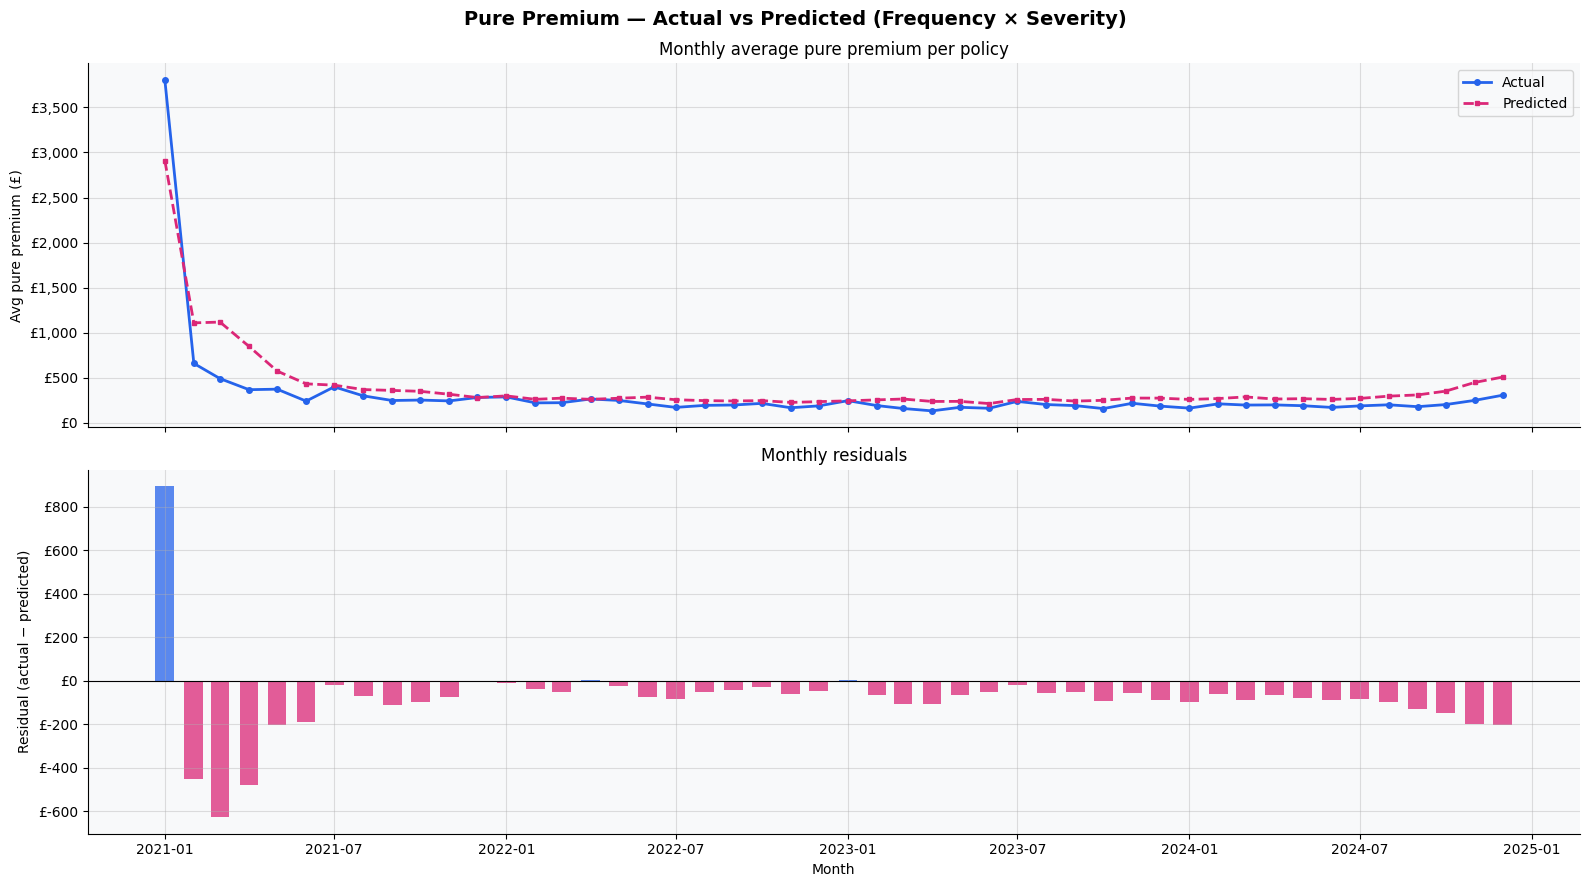

In [25]:
pp_clean = pp_clean.copy()
pp_clean['year_month_int'] = pd.PeriodIndex(pp_clean['year_month'], freq='M').year * 12 + \
                             pd.PeriodIndex(pp_clean['year_month'], freq='M').month

monthly_pp = (pp_clean
    .groupby('year_month_int')[['actual_pure_premium', 'pred_pure_premium']]
    .mean()
    .reset_index()
    .sort_values('year_month_int')
)
monthly_pp['date'] = monthly_pp['year_month_int'].apply(int_to_timestamp)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Pure Premium — Actual vs Predicted (Frequency × Severity)', fontsize=14, fontweight='bold')

axes[0].plot(monthly_pp['date'], monthly_pp['actual_pure_premium'],
             color='#2563eb', linewidth=2, marker='o', markersize=4, label='Actual')
axes[0].plot(monthly_pp['date'], monthly_pp['pred_pure_premium'],
             color='#db2777', linewidth=2, linestyle='--', marker='s', markersize=3, label='Predicted')
axes[0].set_ylabel('Avg pure premium (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].legend()
axes[0].set_title('Monthly average pure premium per policy')

monthly_pp['residual'] = monthly_pp['actual_pure_premium'] - monthly_pp['pred_pure_premium']
axes[1].bar(monthly_pp['date'], monthly_pp['residual'],
            color=monthly_pp['residual'].apply(lambda x: '#2563eb' if x >= 0 else '#db2777'),
            alpha=0.75, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].set_ylabel('Residual (actual − predicted)')
axes[1].set_xlabel('Month')
axes[1].set_title('Monthly residuals')

plt.tight_layout()
plt.show()

## 4. Pure Premium Table by Segment

In [26]:
# Summary table: average pure premium per (coverage_type, region) across all months
pp_summary = (pp_clean
    .groupby(['coverage_type', 'region'])
    .agg(
        actual_pp   =('actual_pure_premium',  'mean'),
        predicted_pp=('pred_pure_premium',    'mean'),
        months      =('year_month',           'count'),
        exposure    =('exposure',             'mean'),
    )
    .reset_index()
)
pp_summary['residual']  = (pp_summary['actual_pp'] - pp_summary['predicted_pp']).round(2)
pp_summary['abs_error'] = pp_summary['residual'].abs().round(2)
pp_summary['actual_pp']    = pp_summary['actual_pp'].round(2)
pp_summary['predicted_pp'] = pp_summary['predicted_pp'].round(2)
pp_summary['exposure']     = pp_summary['exposure'].round(0).astype(int)

pp_summary = pp_summary.sort_values(['coverage_type', 'region']).reset_index(drop=True)

print(f"Segments: {len(pp_summary)}   "
      f"MAE=£{pp_summary['abs_error'].mean():,.2f}   "
      f"Relative MAE={pp_summary['abs_error'].mean()/pp_summary['actual_pp'].mean()*100:.1f}%")
pp_summary

Segments: 60   MAE=£85.56   Relative MAE=38.5%


,coverage_type,region,actual_pp,predicted_pp,months,exposure,residual,abs_error
0,Commercial,East Anglia,346.84,388.53,30,103,-41.69,41.69
1,Commercial,London,330.77,401.43,27,91,-70.66,70.66
2,Commercial,Midlands,317.16,410.47,28,95,-93.31,93.31
3,Commercial,North East,254.26,399.75,34,91,-145.49,145.49
4,Commercial,North West,293.12,519.76,28,84,-226.63,226.63
5,Commercial,Scotland,363.77,545.79,31,83,-182.02,182.02
6,Commercial,South East,314.82,514.70,33,90,-199.88,199.88
7,Commercial,South West,389.97,441.13,29,82,-51.16,51.16
8,Commercial,Wales,312.83,414.87,29,91,-102.04,102.04
9,Commercial,Yorkshire,235.75,420.59,30,103,-184.84,184.84
